# Content Chapters
Use the Outline panel to click and jump to any chapter.
## Table of Contents
- [1. Some basic analysis on total rewards](#1-some-basic-analysis): Check if the AI is performing better than human play as a preliminary analysis
- [2. Action distance analysis](#2-action-distance-analysis)

## 1. Some basic analysis

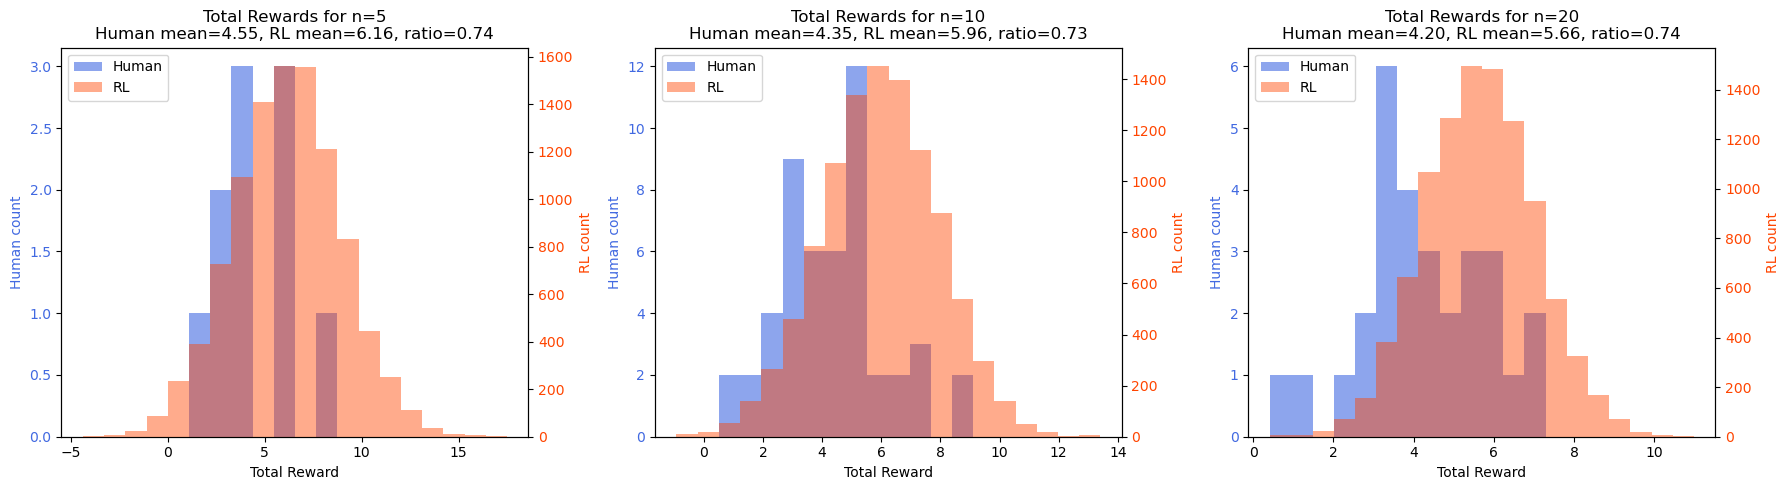

In [1]:
# check the human and rl performance for n=5,10,20
from call_in_data import *
from avgperformance import *
import matplotlib.pyplot as plt
import pandas as pd
import os 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

total_scores_dict = {}
for n in [5,10,20]:
    playdf,_ = call_in_data(n=n)
    total_scores = []
    for i in range(len(playdf)):
        total_scores.append(playdf[i]['total_rewards'])
    total_scores_dict[n] = total_scores
        
# get rl performance for n=5,10,20
n20filename = './human_play_results/RL_performance_summary_seed252358_n20.csv'
n10filename = './human_play_results/RL_performance_summary_seed398845_n10.csv'
n5filename = './human_play_results/RL_performance_summary_seed578396_n5.csv'
# read in the csv files
summaryn20 = pd.read_csv(n20filename)
summaryn10 = pd.read_csv(n10filename)
summaryn5 = pd.read_csv(n5filename)
# first row is summary, get rid 
summaryn20 = summaryn20.iloc[1:]
summaryn10 = summaryn10.iloc[1:]
summaryn5 = summaryn5.iloc[1:]

rl_summary = {
    5: summaryn5['rewards'].astype(float),
    10: summaryn10['rewards'].astype(float),
    20: summaryn20['rewards'].astype(float),
}

# set up subplots
fig, axs = plt.subplots(1, 3, figsize=(18, 5))

for i, n in enumerate([5, 10, 20]):
    human_rewards = pd.Series(total_scores_dict[n], dtype=float)
    rl_rewards = rl_summary[n]

    # Use shared bin edges so both histograms align visually.
    all_rewards = pd.concat([human_rewards, rl_rewards], ignore_index=True)
    bins = pd.cut(all_rewards, bins=20, retbins=True)[1]

    ax_human = axs[i]
    ax_rl = ax_human.twinx()

    ax_human.hist(human_rewards, bins=bins, color='royalblue', alpha=0.60, label='Human')
    ax_rl.hist(rl_rewards, bins=bins, color='orangered', alpha=0.45, label='RL')

    human_mean = human_rewards.mean()
    rl_mean = rl_rewards.mean()
    ax_human.set_title(f'Total Rewards for n={n}\nHuman mean={human_mean:.2f}, RL mean={rl_mean:.2f}, ratio={human_mean/rl_mean:.2f}')
    ax_human.set_xlabel('Total Reward')
    ax_human.set_ylabel('Human count', color='royalblue')
    ax_rl.set_ylabel('RL count', color='orangered')
    ax_human.tick_params(axis='y', labelcolor='royalblue')
    ax_rl.tick_params(axis='y', labelcolor='orangered')

    # Combined legend for twin axes.
    h1, l1 = ax_human.get_legend_handles_labels()
    h2, l2 = ax_rl.get_legend_handles_labels()
    ax_human.legend(h1 + h2, l1 + l2, loc='upper left')

plt.tight_layout()
plt.show()



n=5, t-statistic=-8.35, p-value=0.0000


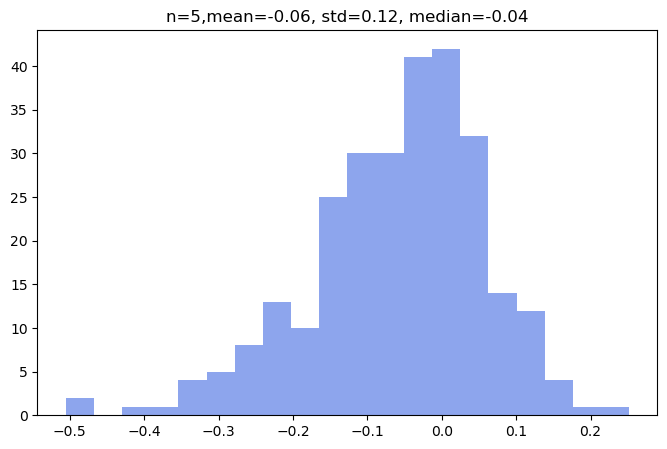

n=10, t-statistic=-10.63, p-value=0.0000


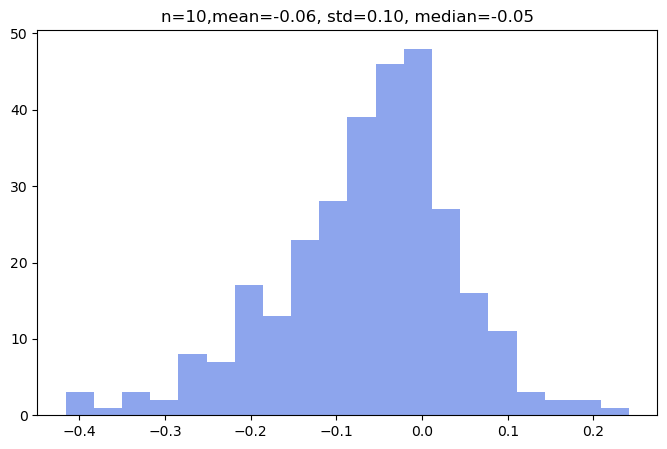

n=20, t-statistic=-11.43, p-value=0.0000


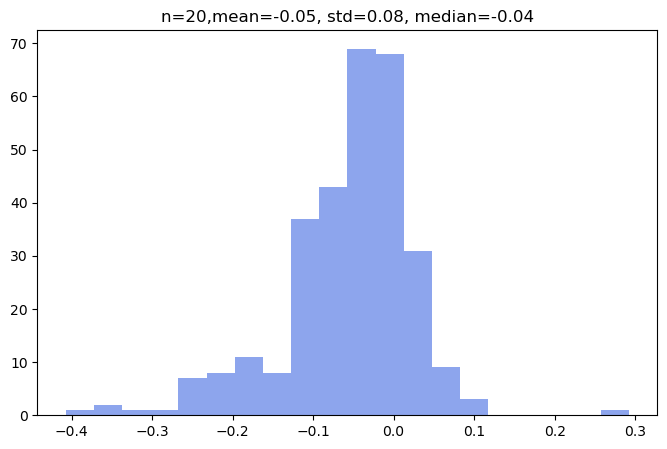

In [30]:
# let's check the value difference for a given state
from call_in_data import *
import matplotlib.pyplot as plt
from scipy import stats
for n  in [5,10,20]:
    playdf,filenames = call_in_data(n=n, with_valdiff=True, merge=True)
    delV, V_human, V_pi = zip(*playdf['performance_gap'])
    # t-test to check if delV is significantly different from 0
    t_stat, p_value = stats.ttest_1samp(delV, 0)
    print(f'n={n}, t-statistic={t_stat:.2f}, p-value={p_value:.4f}')
    
    plt.figure(figsize=(8,5))
    plt.hist(delV, bins=20, color='royalblue', alpha=0.60)
    plt.title(f'n={n},mean={np.mean(delV):.2f}, std={np.std(delV):.2f}, median={np.median(delV):.2f}')
    plt.show()




## 2. Action distance analysis

In [ ]:
# check how value difference changes with different n and different states:
# timestep (t), (important)
# fraction of good habitats, (important)
# fraction of occupied habitats, (important)
# average connectivity, 
# average extinction probability, 
# average colonization probability, 
# restore fraction, 
# supplement fraction
from call_in_data import *
playdf,filenames = call_in_data(n=5, with_valdiff=True,merge=True)
delV, V_human, V_pi = zip(*playdf['performance_gap'])
states = playdf['observations']
t = np.array([s[0,-1] for s in states])
occfrac = playdf['occfraction_per_episode']
goodhfrac = playdf['goodHfraction_per_episode']
avgconn = playdf['avgconnectivity_per_episode']
eprob = playdf['avgeprob_per_episode']
cprob = playdf['avgcprob_per_episode']
restorefrac = playdf['restore_fraction_per_episode']
suppfrac = playdf['supp_fraction_per_episode']



In [ ]:
# plot action distance histogram for n=5,10,20
from call_in_data import *
import matplotlib.pyplot as plt
playdf, _ = call_in_data(n=5, with_valdiff=True, merge=True)
adist = playdf['L1_a_dist_RLsampled_a_prob']
adist
#plt.figure(figsize=(8,5))
#plt.hist(adist, bins=20, color='royalblue', alpha=0.60)


In [ ]:
#1. action dist vs value difference (by action type (S or R ) and by all)

# 2. action dist vs state variables

# do higher cost actions have higher value difference?

# calculate action and value difference for heuristics. 

# make visualization of RL play to understand what the RL is doing and how it 
# differs from human play so i can better plan what kind of states i should look
# into for understanding the value difference and action difference.

# incoming dispersal weight weighted occ fraction
# incoming dispersal weight and habitat quality weighted occ fraction